In [1]:
import os 
import time 
import pandas as pd
import numpy as np
import unicodedata
from collections import Counter
import matplotlib.pyplot as plt

## Folder

In [2]:
tables_valid_folder = r"D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid\tables"
tables_test_folder = r"D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Test\tables"

valid_folder = r"D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid"
test_folder = r"D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Test"

os.makedirs(r"D:\Thesis\Code\Clean\thesis\EDA\output", exist_ok=True)

## EDA

In [ ]:
print("Number of tables in valid folder:", len(os.listdir(tables_valid_folder)))
print("Number of tables in test folder:", len(os.listdir(tables_test_folder)))

In [ ]:
def number_of_elements_in_csv(folder):
    cpa_targets_valid = pd.read_csv(os.path.join(folder, "targets/cpa_targets.csv"))
    cta_targets_valid = pd.read_csv(os.path.join(folder, "targets/cta_targets.csv"))
    cea_targets_valid = pd.read_csv(os.path.join(folder, "targets/cea_targets.csv"))
    print("Number of rows in cpa_targets.csv in folder", folder, ":", len(cpa_targets_valid))
    print("Number of rows in cta_targets.csv in folder", folder, ":", len(cta_targets_valid))
    print("Number of rows in cea_targets.csv in folder", folder, ":", len(cea_targets_valid))
    return len(cpa_targets_valid), len(cta_targets_valid), len(cea_targets_valid)


def unique_ground_truth_entities(folder):
    cpa_gt = pd.read_csv(os.path.join(folder, "gt/cpa_gt.csv"),header=None, names=["table_id", "col1", "col2", "label"])
    cta_gt = pd.read_csv(os.path.join(folder, "gt/cta_gt.csv"),header=None, names=["table_id", "col", "label"])
    cea_gt = pd.read_csv(os.path.join(folder, "gt/cea_gt.csv"),header=None, names=["table_id", "row", "col", "label"])

    unique_entities_cpa = set(cpa_gt["label"])  
    unique_entities_cta = set(cta_gt["label"])   
    unique_entities_cea = set(cea_gt["label"])  

    print("Number of unique properties in cpa_gt.csv in folder", folder, ":", len(unique_entities_cpa))
    print("Number of unique types in cta_gt.csv in folder", folder, ":", len(unique_entities_cta))
    print("Number of unique entities in cea_gt.csv in folder", folder, ":", len(unique_entities_cea))

    return unique_entities_cpa, unique_entities_cta, unique_entities_cea


In [8]:
cpa_number,cta_number,cea_number = number_of_elements_in_csv(valid_folder)
cpa_number_test,cta_number_test,cea_number_test = number_of_elements_in_csv(test_folder)

print("Proportion of CPA valid against test:", cpa_number /  cpa_number_test)
print("Proportion of CTA valid against test:", cta_number /  cta_number_test)
print("Proportion of CEA valid against test:", cea_number /  cea_number_test)

unique_entities_cpa_valid, unique_entities_cta_valid, unique_entities_cea_valid = unique_ground_truth_entities(valid_folder)
unique_entities_cpa_test, unique_entities_cta_test, unique_entities_cea_test = unique_ground_truth_entities(test_folder)

print("Proportion of unique properties in cpa_gt.csv valid against test:", len(unique_entities_cpa_valid) / len(unique_entities_cpa_test))
print("Proportion of unique types in cta_gt.csv valid against test:", len(unique_entities_cta_valid) / len(unique_entities_cta_test))
print("Proportion of unique entities in cea_gt.csv valid against test:", len(unique_entities_cea_valid) / len(unique_entities_cea_test))

print("Unique properties in cpa_gt.csv valid:",len(unique_entities_cpa_valid) )
print("Unique types in cta_gt.csv valid:", len(unique_entities_cta_valid) )
print("Unique entities in cea_gt.csv valid:", len(unique_entities_cea_valid) )

print("Unique properties in cpa_gt.csv test:", len(unique_entities_cpa_test) )
print("Unique types in cta_gt.csv test:", len(unique_entities_cta_test) )
print("Unique entities in cea_gt.csv test:", len(unique_entities_cea_test) )

Number of rows in cpa_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid : 709
Number of rows in cta_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid : 622
Number of rows in cea_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid : 4246
Number of rows in cpa_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Test : 44951
Number of rows in cta_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Test : 36625
Number of rows in cea_targets.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Test : 2276094
Proportion of CPA valid against test: 0.015772730306333565
Proportion of CTA valid against test: 0.01698293515358362
Proportion of CEA valid against test: 0.0018654765576465646
Number of unique properties in cpa_gt.csv in folder D:\Thesis\Dataset\2024\WikidataTables2024R1\DataSets\Valid : 177
Number of unique types in cta_gt.csv in folder

In [9]:
def count_numeric_columns_in_folder(folder):
    numeric_columns = 0
    total_columns = 0

    for file in os.listdir(folder):
        if file.endswith(".csv"):
            path = os.path.join(folder, file)
            df = pd.read_csv(path)

            total_columns += df.shape[1]

            numeric_cols = df.select_dtypes(include=[np.number]).columns
            numeric_columns += len(numeric_cols)

    return numeric_columns, total_columns
            

numeric_columns_valid, total_columns_valid = count_numeric_columns_in_folder(tables_valid_folder)
numeric_columns_test, total_columns_test = count_numeric_columns_in_folder(tables_test_folder)
print("Number of numeric columns in valid folder:", numeric_columns_valid, "out of", total_columns_valid)
print("Number of numeric columns in test folder:", numeric_columns_test, "out of", total_columns_test)
print("Proportion of numeric columns in valid folder:", numeric_columns_valid / total_columns_valid)
print("Proportion of numeric columns in test folder:", numeric_columns_test / total_columns_test)

Number of numeric columns in valid folder: 441 out of 1231
Number of numeric columns in test folder: 31451 out of 76337
Proportion of numeric columns in valid folder: 0.35824532900081235
Proportion of numeric columns in test folder: 0.4120020435699595


## TOKENS

In [10]:
USELESS_TOKENS = set("""
the of and in to a an for on at by as is are was with from that this it its or be
de la le les des du et en un une au aux pour par dans sur avec se sa son ses qui ne
der die das und von zu im mit den dem ein eine ist
el los las y por con para del al una su lo
da do dos das no na em uma
""".split())
def _clean_token(tok):
    tok = unicodedata.normalize("NFKC", tok).strip()

    while tok and unicodedata.category(tok[0]).startswith(("P", "S")):
        tok = tok[1:]
    while tok and unicodedata.category(tok[-1]).startswith(("P", "S")):
        tok = tok[:-1]

    return tok
def most_frequent_tokens_whitespace_folder(folder,output_path,top_k = 1000,min_len = 2,lowercase= True,output_format = "csv",):
    counter = Counter()
    for f in os.listdir(folder):
        if not f.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder, f), low_memory=False)
        for col in df.select_dtypes(include=["object", "string"]).columns:
            for s in df[col].dropna().astype(str):
                for tok in s.lower().split():
                    tok = _clean_token(tok)
                    if len(tok) >= min_len and tok not in USELESS_TOKENS and not tok.isnumeric():
                        counter[tok] += 1

    most_common = counter.most_common(top_k)
    out_df = pd.DataFrame(most_common, columns=["token", "count"])

    if output_format == "csv":
        out_df.to_csv(output_path, index=False, encoding="utf-8")
    elif output_format == "json":
        out_df.to_json(output_path, orient="records", force_ascii=False, indent=2)
    else:
        raise ValueError("Unsupported output format: {}".format(output_format))

    return out_df

            token  count
0          county    134
1        universe     56
2        heritage     53
3       insurance     47
4        monument     47
5   architectural     45
6         bavaria     44
7         station     41
8           stall     40
9            line     35
10         planta     31
11       township     31
12            eso     29
13          death     29
14           john     28
15            dam     27
16         museum     26
17          saint     26
18            art     25
19         center     24
            token  count
0          united  26250
1         station  24234
2              hd  23892
3          season  20206
4        election  19272
5           2mass  18437
6          states  17362
7         library  17036
8            sdss  16524
9           house  16466
10       national  14923
11        america  13616
12       district  13543
13         county  13352
14           ogle  12550
15           naid  12399
16  international  12355
17         church  11785


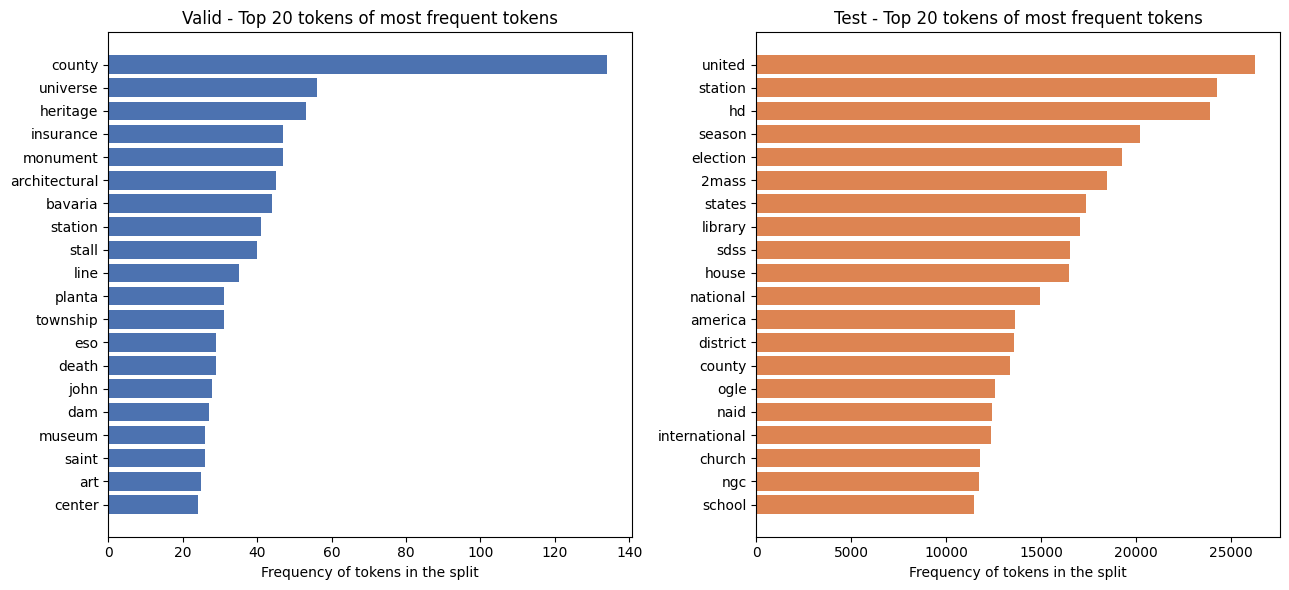

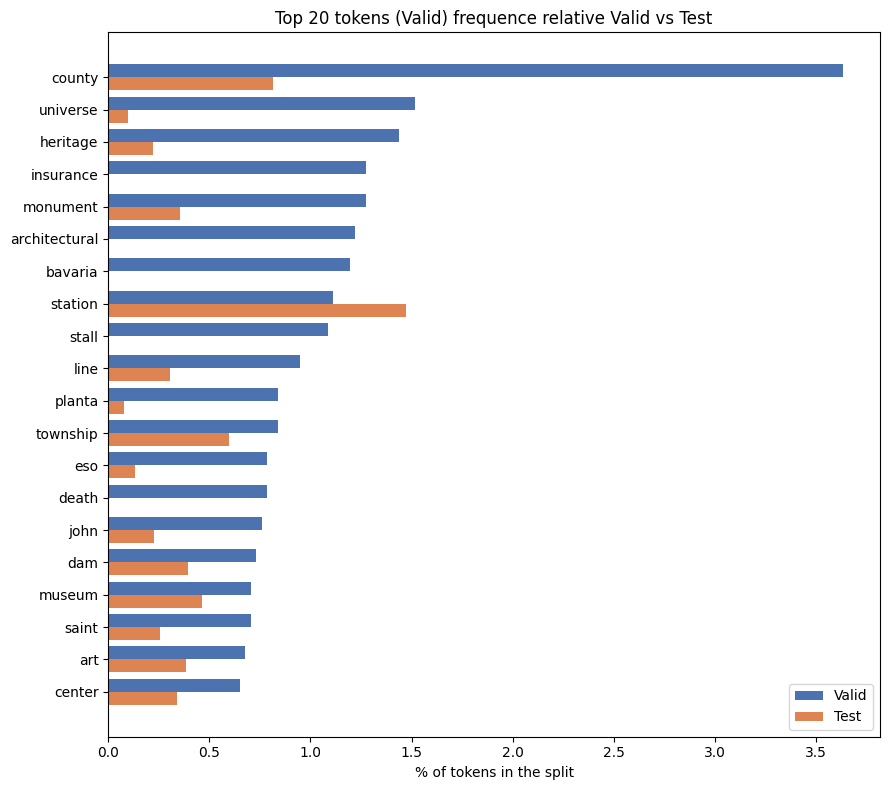

In [15]:
df_valid = most_frequent_tokens_whitespace_folder(tables_valid_folder, "output/most_frequent_tokens_valid.csv", top_k=500, min_len=2, lowercase=True, output_format="csv")

print(df_valid.head(20))

df_test = most_frequent_tokens_whitespace_folder(tables_test_folder, "output/most_frequent_tokens_test.csv", top_k=500, min_len=2, lowercase=True, output_format="csv")
print(df_test.head(20))


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, df, name, color in [(axes[0], df_valid, "Valid", "#4C72B0"),
                            (axes[1], df_test,  "Test",  "#DD8452")]:
    top = df.head(20).iloc[::-1]          
    ax.barh(top["token"], top["count"], color=color)
    ax.set_title(f"{name} - Top 20 tokens of most frequent tokens") 
    ax.set_xlabel("Frequency of tokens in the split")

plt.tight_layout()
plt.savefig("output/top20_tokens.png", dpi=200, bbox_inches="tight")
plt.show()

top_tokens = df_valid.head(20)["token"]
v = df_valid.set_index("token")["count"]
t = df_test.set_index("token")["count"]
vr = (v / v.sum() * 100).reindex(top_tokens)
tr = (t / t.sum() * 100).reindex(top_tokens).fillna(0)

y = np.arange(len(top_tokens)); h = 0.4
plt.figure(figsize=(9, 8))
plt.barh(y + h/2, vr[::-1], h, label="Valid", color="#4C72B0")
plt.barh(y - h/2, tr[::-1], h, label="Test",  color="#DD8452")
plt.yticks(y, top_tokens[::-1])
plt.xlabel("% of tokens in the split"); plt.legend()
plt.title("Top 20 tokens (Valid) frequence relative Valid vs Test")
plt.tight_layout(); plt.savefig("output/top20_tokens_compare.png", dpi=200, bbox_inches="tight")
plt.show()


In [18]:
def count_columns_litterals_ne(folder):
    ne_counts = []
    litterals_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            ne_count = 0
            litterals_count = 0
            for column in df.columns:
                if df[column].dtype == 'object':
                    ne_count += 1
                else:
                    litterals_count += 1
            ne_counts.append(ne_count)
            litterals_counts.append(litterals_count)
    return ne_counts, litterals_counts

def plot_barred_counts(ne_counts, litterals_counts,title):
    labels = ['NE Columns', 'Literal Columns']
    counts = [sum(ne_counts), sum(litterals_counts)]
    
    x = np.arange(len(labels))
    fig, ax = plt.subplots()
    bars = ax.bar(x, counts, color=['blue', 'orange'])
    
    ax.set_ylabel('Counts')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    
    for bar in bars:
        height = bar.get_height()
        ax.annotate('{}'.format(height),
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')
    
    plt.show()

def count_number_of_tables(folder):
    count = 0
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            count += 1
    return count

def statistics_columns_per_table(folder):
    columns_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            columns_counts.append(len(df.columns))
    return {
        'mean': np.mean(columns_counts),
        'median': np.median(columns_counts),
        'std_dev': np.std(columns_counts),
        'min': np.min(columns_counts),
        'max': np.max(columns_counts)
    }
def count_elements(folder):
    total_elements = 0
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            total_elements += df.size
    return total_elements

def count_elements_ne_litterals(folder):
    total_ne = 0
    total_literals = 0
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                if df[column].dtype == 'object':
                    total_ne += df[column].count()
                else:
                    total_literals += df[column].count()
    return total_ne, total_literals

def statistics_entities_per_column(folder):
    entities_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                entities_counts.append(df[column].count())
    return {
        'mean': np.mean(entities_counts),
        'median': np.median(entities_counts),
        'std_dev': np.std(entities_counts),
        'min': np.min(entities_counts),
        'max': np.max(entities_counts)
    }
def nan_number(folder):
    nan_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                nan_counts.append(df[column].isna().sum())
    return nan_counts
def quartile_10(folder):
    entities_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                entities_counts.append(df[column].count())
    for i in range(1, 11):
        print(f"{i*10}th Percentile: {np.percentile(entities_counts, i*10)}")
    
    
def plot_histogram_entities_per_column(folder, title, log_scale=False):
    entities_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                entities_counts.append(df[column].count())
    
    plt.hist(entities_counts, bins=30, color='green', alpha=0.7)
    plt.title(title)
    plt.xlabel('Number of Entities per Column')
    plt.ylabel('Frequency')
    if log_scale:
        plt.yscale('log')
    plt.savefig(f"output/histogram_{title.replace(' ', '_').lower()}.png")
    plt.show()

def plot_boxplot_entities_per_column(folder, title, log_scale=False):
    entities_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            for column in df.columns:
                entities_counts.append(df[column].count())
    
    plt.boxplot(entities_counts)
    plt.title(title)
    plt.ylabel('Number of Entities per Column')
    if log_scale:
        plt.yscale('log')
    plt.savefig(f"output/boxplot_{title.replace(' ', '_').lower()}.png")
    plt.show()
            

Number of tables in WikidataTables2024R1 Valid Set: 500
NE Counts: 790
Literals Counts: 441
Nan Counts: 751
Statistics of columns per table in WikidataTables2024R1 Valid Set: {'mean': np.float64(2.462), 'median': np.float64(2.0), 'std_dev': np.float64(0.6697432343816546), 'min': np.int64(2), 'max': np.int64(4)}
Total Elements in WikidataTables2024R1 Valid Set: 7306
Total NE and Literal Elements in WikidataTables2024R1 Valid Set: (np.int64(4354), np.int64(2201))
Statistics of entities per column in WikidataTables2024R1 Valid Set: {'mean': np.float64(5.324939073923639), 'median': np.float64(5.0), 'std_dev': np.float64(2.7765444938090176), 'min': np.int64(1), 'max': np.int64(10)}


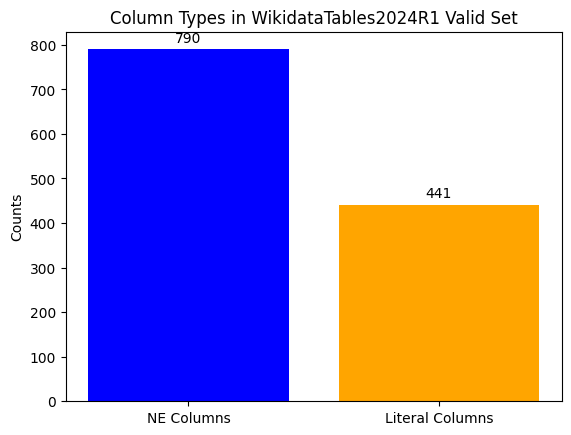

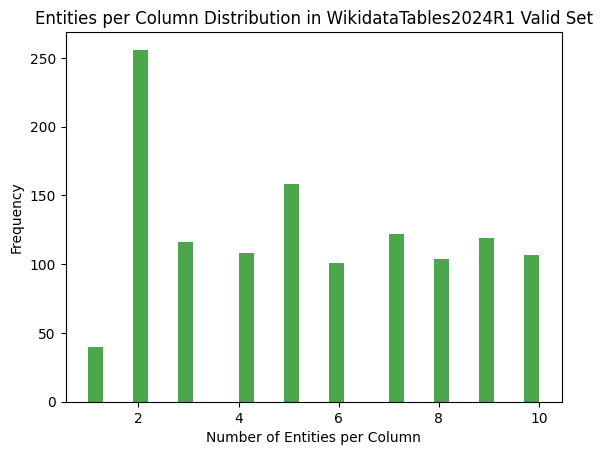

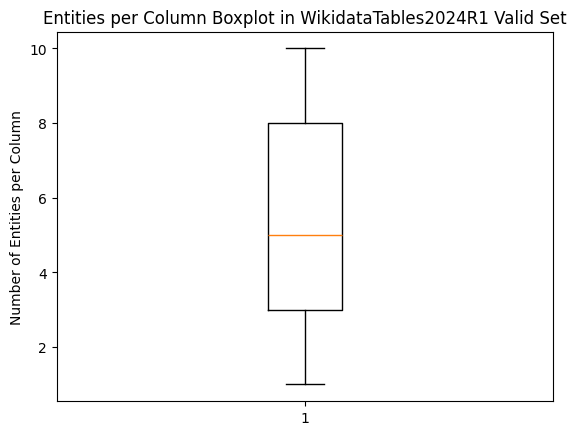

In [19]:
print("Number of tables in WikidataTables2024R1 Valid Set:", count_number_of_tables(tables_valid_folder))
ne_counts, litterals_counts = count_columns_litterals_ne(tables_valid_folder)

print("NE Counts:", sum(ne_counts))
print("Literals Counts:", sum(litterals_counts))
print("Nan Counts:", sum(nan_number(tables_valid_folder)))
print("Statistics of columns per table in WikidataTables2024R1 Valid Set:", statistics_columns_per_table(tables_valid_folder))
print("Total Elements in WikidataTables2024R1 Valid Set:", count_elements(tables_valid_folder))
print("Total NE and Literal Elements in WikidataTables2024R1 Valid Set:", count_elements_ne_litterals(tables_valid_folder))
print("Statistics of entities per column in WikidataTables2024R1 Valid Set:", statistics_entities_per_column(tables_valid_folder))

plot_barred_counts(ne_counts, litterals_counts,"Column Types in WikidataTables2024R1 Valid Set")
plot_histogram_entities_per_column(tables_valid_folder, "Entities per Column Distribution in WikidataTables2024R1 Valid Set")
plot_boxplot_entities_per_column(tables_valid_folder, "Entities per Column Boxplot in WikidataTables2024R1 Valid Set")

Number of tables in WikidataTables2024R1 Test Set: 30000
NE Counts: 44886
Literals Counts: 31451
Nan Counts: 1134453
Statistics of columns per table in WikidataTables2024R1 Test Set: {'mean': np.float64(2.544566666666667), 'median': np.float64(2.0), 'std_dev': np.float64(0.7826539117359316), 'min': np.int64(2), 'max': np.int64(10)}
Total Elements in WikidataTables2024R1 Test Set: 4378387
Total NE and Literal Elements in WikidataTables2024R1 Test Set: (np.int64(2363189), np.int64(880745))
Statistics of entities per column in WikidataTables2024R1 Test Set: {'mean': np.float64(42.49491072481234), 'median': np.float64(2.0), 'std_dev': np.float64(141.3139967589283), 'min': np.int64(1), 'max': np.int64(1000)}


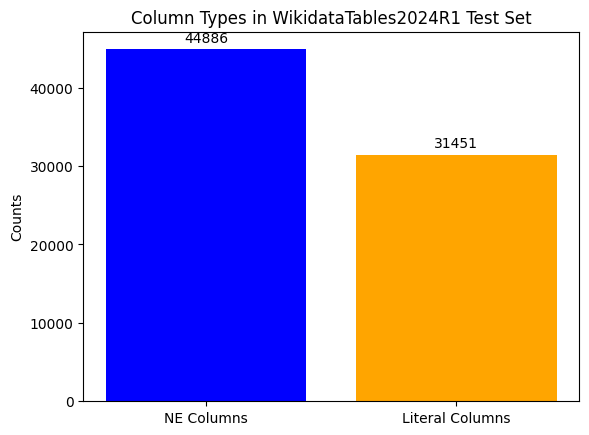

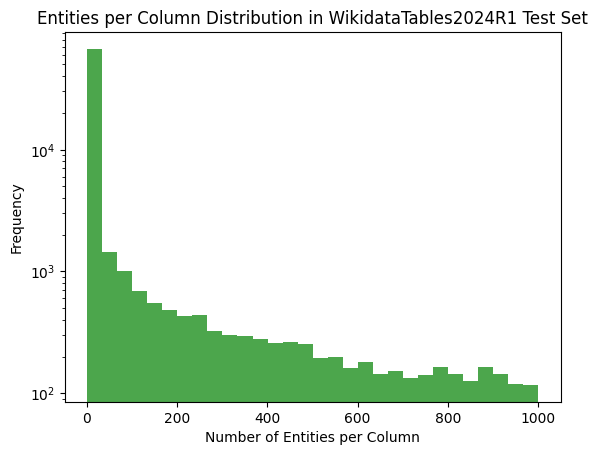

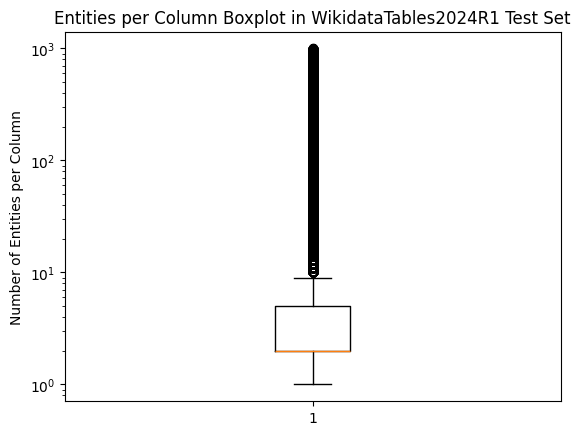

In [20]:
print("Number of tables in WikidataTables2024R1 Test Set:", count_number_of_tables(tables_test_folder))
ne_counts, litterals_counts = count_columns_litterals_ne(tables_test_folder)

print("NE Counts columns:", sum(ne_counts))
print("Literals Counts columns:", sum(litterals_counts))
print("Nan Counts:", sum(nan_number(tables_test_folder)))
print("Statistics of columns per table in WikidataTables2024R1 Test Set:", statistics_columns_per_table(tables_test_folder))
print("Total Elements in WikidataTables2024R1 Test Set:", count_elements(tables_test_folder))
print("Total NE and Literal Elements in WikidataTables2024R1 Test Set:", count_elements_ne_litterals(tables_test_folder))
print("Statistics of entities per column in WikidataTables2024R1 Test Set:", statistics_entities_per_column(tables_test_folder))

plot_barred_counts(ne_counts, litterals_counts,"Column Types in WikidataTables2024R1 Test Set")
plot_histogram_entities_per_column(tables_test_folder, "Entities per Column Distribution in WikidataTables2024R1 Test Set", log_scale=True)
plot_boxplot_entities_per_column(tables_test_folder, "Entities per Column Boxplot in WikidataTables2024R1 Test Set", log_scale=True)

{'mean': 5.952, 'median': 6.0, 'std': 2.772308785110346, 'min': 2, 'max': 10}


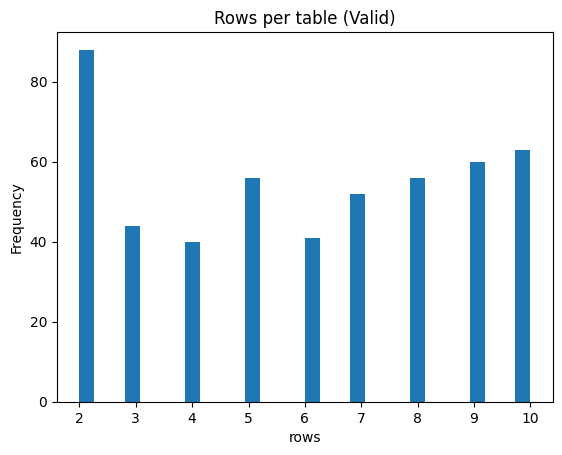

mean NaN ratio: 0.0915095238095238


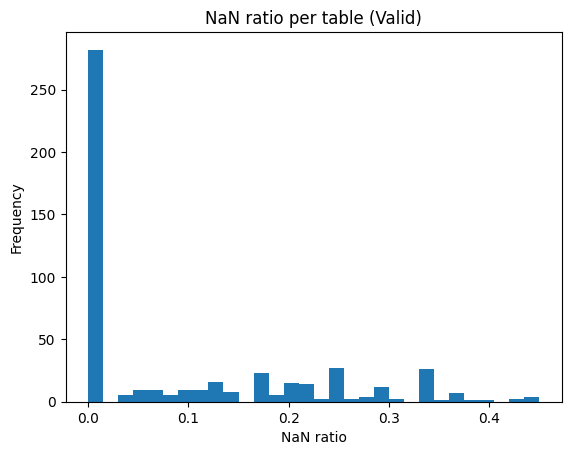

In [22]:
def nan_ratio_per_table(folder):
    ratios = []
    for f in os.listdir(folder):
        if f.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, f), low_memory=False)
            ratios.append(df.isna().mean().mean()) 
    return ratios

def stats_rows_per_table(folder):
    rows = []
    for f in os.listdir(folder):
        if f.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, f), low_memory=False)
            rows.append(len(df))
    return {"mean": float(np.mean(rows)),"median": float(np.median(rows)),"std": float(np.std(rows)),"min": int(np.min(rows)),"max": int(np.max(rows)),}, rows

stats, rows = stats_rows_per_table(tables_valid_folder)
print(stats)
plt.hist(rows, bins=30)
plt.title("Rows per table (Valid)")
plt.xlabel("rows")
plt.ylabel("Frequency")
plt.savefig("output/histogram_rows_per_table_valid.png")
plt.show()


ratios = nan_ratio_per_table(tables_valid_folder)
print("mean NaN ratio:", float(np.mean(ratios)))
plt.hist(ratios, bins=30)
plt.title("NaN ratio per table (Valid)")
plt.xlabel("NaN ratio")
plt.ylabel("Frequency")
plt.savefig("output/histogram_nan_ratio_per_table_valid.png")
plt.show()

{'mean': 61.7162, 'median': 2.0, 'std': 178.7113254876702, 'min': 2, 'max': 1000}


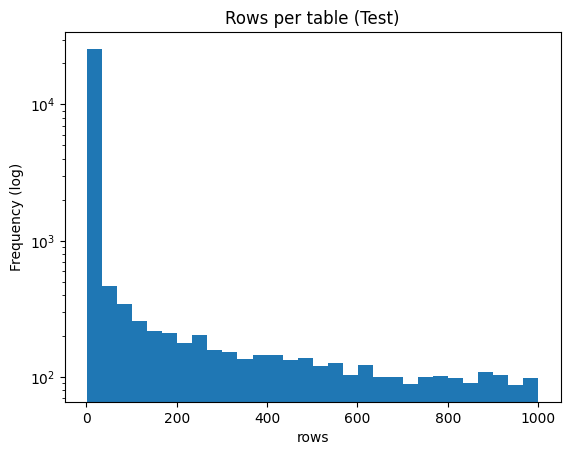

mean NaN ratio: 0.06576005139532111


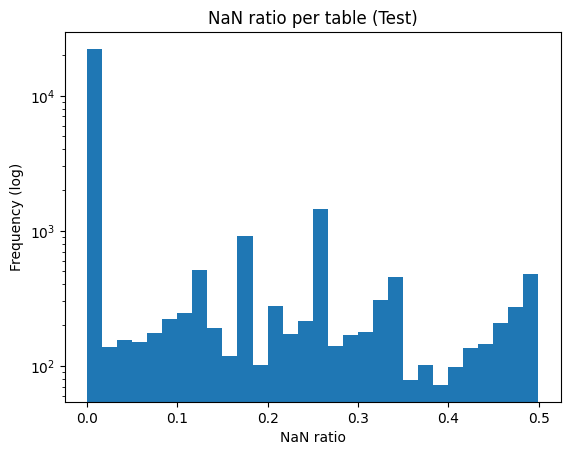

In [24]:
stats, rows = stats_rows_per_table(tables_test_folder)
print(stats)
plt.hist(rows, bins=30)
plt.yscale("log")
plt.title("Rows per table (Test)")
plt.xlabel("rows")
plt.ylabel("Frequency (log)")
plt.savefig("output/histogram_rows_per_table_test.png", dpi=200, bbox_inches="tight")
plt.show()

ratios = nan_ratio_per_table(tables_test_folder)
print("mean NaN ratio:", float(np.mean(ratios)))
plt.hist(ratios, bins=30)
plt.yscale("log")
plt.title("NaN ratio per table (Test)")
plt.xlabel("NaN ratio")
plt.ylabel("Frequency (log)")
plt.savefig("output/histogram_nan_ratio_per_table_test.png", dpi=200, bbox_inches="tight")
plt.show()


In [27]:
def statistics_words_per_cell(folder):
    word_counts = []
    for filename in os.listdir(folder):
        if not filename.endswith(".csv"):
            continue
        df = pd.read_csv(os.path.join(folder, filename), low_memory=False)
        text_cols = df.select_dtypes(exclude=[np.number]).columns
        for column in text_cols:
            for value in df[column].dropna().astype(str):
                word_counts.append(len(value.split()))
    return {
        'mean': np.mean(word_counts),
        'median': np.median(word_counts),
        'std_dev': np.std(word_counts),
        'min': np.min(word_counts),
        'max': np.max(word_counts),
        'n_cells': len(word_counts),
    }

def words_per_cell_list(folder):
    counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename), low_memory=False)
            for column in df.select_dtypes(exclude=[np.number]).columns:
                counts.extend(len(v.split()) for v in df[column].dropna().astype(str))
    return counts



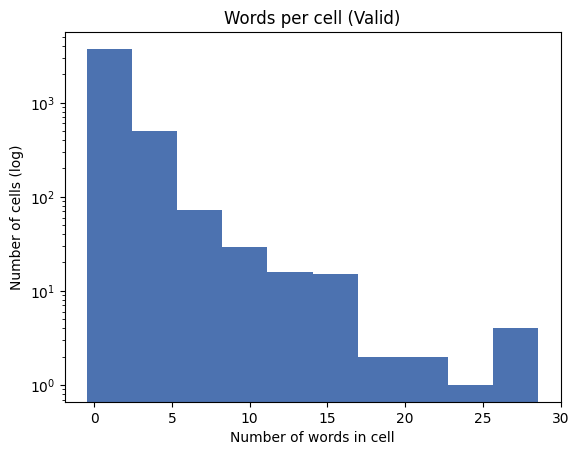

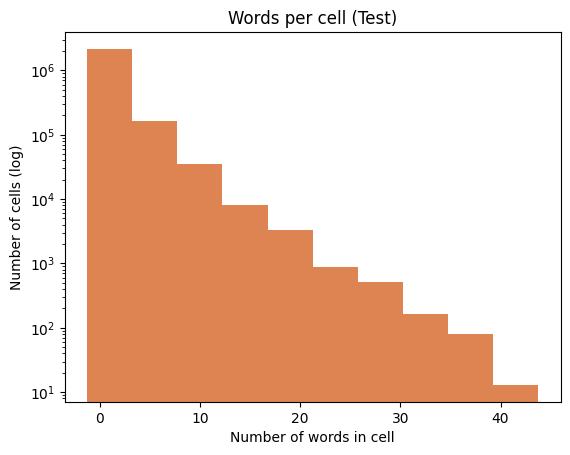

In [29]:
counts = words_per_cell_list(tables_valid_folder)
plt.hist(counts, align="left", color="#4C72B0")
plt.yscale("log")
plt.xlabel("Number of words in cell")
plt.ylabel("Number of cells (log)")
plt.title("Words per cell (Valid)")
plt.savefig("output/words_per_cell_valid.png", dpi=200, bbox_inches="tight")
plt.show()

counts = words_per_cell_list(tables_test_folder)
plt.hist(counts, align="left", color="#DD8452")
plt.yscale("log")
plt.xlabel("Number of words in cell")
plt.ylabel("Number of cells (log)")
plt.title("Words per cell (Test)")
plt.savefig("output/words_per_cell_test.png", dpi=200, bbox_inches="tight")
plt.show()

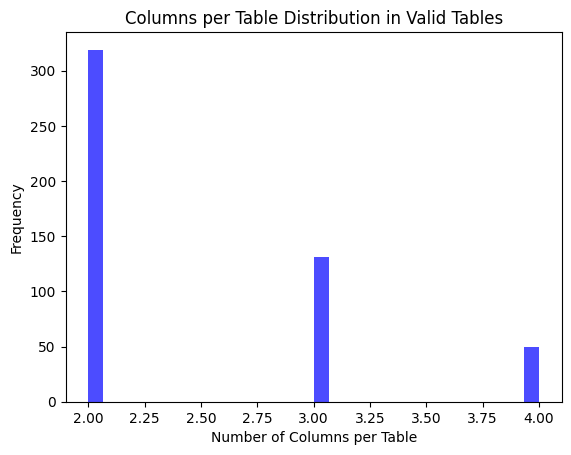

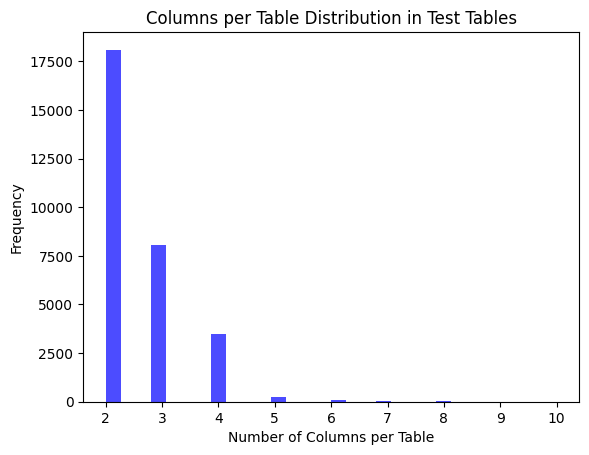

In [7]:
def show_columns_per_table(folder, title):
    columns_counts = []
    for filename in os.listdir(folder):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(folder, filename))
            columns_counts.append(len(df.columns))
    plt.hist(columns_counts, bins=30, color='blue', alpha=0.7)
    plt.title(f"Columns per Table Distribution in {title}")
    plt.xlabel('Number of Columns per Table')
    plt.ylabel('Frequency')
    plt.savefig(f"output/columns_per_table_{os.path.basename(title)}.png", dpi=200, bbox_inches="tight")
    plt.show()

show_columns_per_table(tables_valid_folder, "Valid Tables")
show_columns_per_table(tables_test_folder, "Test Tables")
    
